## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [1]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 전용: 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 시각화 그래프
import warnings
warnings.filterwarnings('ignore')

print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (34.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 3: OOS 발생 예측 모델 구축 ⭐⭐⭐ 중급

### 🏭 배경 설명

**사후 대응에서 사전 예방으로의 전환**은 현대 GMP의 핵심 철학입니다.
기존에는 OOS(Out of Specification)가 발생한 **후에** 원인을 조사했지만,
AI 예측 모델을 활용하면 제조 과정의 공정 데이터를 분석하여 **최종 검사 전에**
OOS 가능성을 예측하고 선제적 조치를 취할 수 있습니다.

**Random Forest 알고리즘 원리:**
- 수많은 결정 트리(Decision Tree)를 만들어 다수결로 예측하는 **앙상블 방법**
- 각 변수의 중요도(Feature Importance)를 계산하여 **어떤 공정 변수가 OOS에 영향을 주는지** 파악
- 과적합(Overfitting)에 강하고, 해석이 비교적 쉬운 장점

**이 예제에서 배우는 것:**
- 공정 파라미터 데이터로 OOS 예측 모델 학습
- 훈련/검증 데이터 분리 및 모델 성능 평가
- 특성 중요도(Feature Importance) 분석: 어떤 변수가 중요한가?
- 새로운 배치의 OOS 확률 예측 (실시간 예측 시뮬레이션)

**가상 시나리오:** 고체 제제(정제) 제조 공정의 과립화~압축 단계 데이터로 최종 함량 OOS를 예측합니다.


---
## 📍 모듈 ② — 예측적 품질관리 | 예제 3: OOS 발생 예측 모델

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **21 CFR 211.192** | OOS 결과 조사 의무 → AI로 OOS **발생 전** 예측해 조사 건수 감소 |
| **ICH Q6A 규격 설정** | OOS/OOT 판단 기준을 ML 분류 경계로 수치화 |
| **ICH Q8(R2) RTRT** | 제조 공정 데이터로 최종 품질 예측 → 출하 검사 가속화 |
| **FDA PAT Guidance** | 공정 분석으로 실시간 품질 보증 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 최종 제품 샘플링 후 OOS 확인 | **Random Forest**로 공정 중 OOS 가능성 예측 | OOS 발생 전 예방 조치 가능 |
| 결정트리 1개 → 과적합 | 수백 개 트리 앙상블 → 일반화 성능 향상 | 검증 배치에서도 안정적 성능 |
| 변수별 개별 한계치 | Feature Importance로 OOS에 기여하는 CPP 순위화 | ICH Q9 Risk Assessment 자동화 |

### 🎯 핵심 Takeaway
> **"예방적 품질 관리(Proactive QC)의 첫 걸음 — 최종 검사 전에 불합격을 예측한다."**

1. **결정 트리(단일) vs 랜덤 포레스트(앙상블)**: 깊은 단일 트리는 훈련 데이터를 암기(과적합)하지만,  
   랜덤 포레스트는 다수결로 일반화 → 실제 배치에 적용 가능한 모델
2. Feature Importance = QbD의 **CPP 중요도 순위** → 공정 제어 우선순위 설정 근거
3. OOS 예측 모델은 FDA 21 CFR Part 11 준수 하에 **RTRT의 과학적 근거**로 활용 가능

### ➡️ 다음 예제
**예제 4 (이상탐지)**: OOS **예측**(지도학습)과 달리, 레이블 없이도 이상을 찾는 **비지도학습** 학습

In [2]:
# =====================================================
# 예제 3: OOS 발생 예측 모델 구축 (Random Forest)
# =====================================================

from sklearn.ensemble import RandomForestClassifier   # 랜덤 포레스트 분류기
from sklearn.model_selection import train_test_split  # 훈련/검증 데이터 분리
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix)

# ─────────────────────────────────────────────────────
# 3-1. 정제 제조 공정 데이터 생성
# 과립화 → 건조 → 혼합 → 압축 → 코팅 → 최종 검사
# ─────────────────────────────────────────────────────

np.random.seed(2026)
n = 500   # 500개 배치

# ── 공정 파라미터 (입력 변수, X) ──
df_tablet = pd.DataFrame({
    # 과립화 단계
    'granule_moisture'  : np.random.normal(3.5, 0.5, n),   # 과립 수분 (%)
    'granule_size_d50'  : np.random.normal(300, 30,  n),   # 과립 크기 D50 (μm)
    # 건조 단계
    'drying_temp_C'     : np.random.normal(60,  5,   n),   # 건조 온도 (°C)
    'drying_time_min'   : np.random.normal(45,  8,   n),   # 건조 시간 (분)
    # 혼합/압축 단계
    'blend_time_min'    : np.random.normal(15,  3,   n),   # 혼합 시간 (분)
    'compaction_force_kN': np.random.normal(12, 2,   n),   # 압축력 (kN)
    'tablet_hardness_N' : np.random.normal(80,  10,  n),   # 정제 경도 (N)
    # 코팅 단계
    'coat_weight_gain'  : np.random.normal(3.0, 0.3, n),   # 코팅 중량 증가율 (%)
})

# ── OOS 발생 여부 (목표 변수, y) ──
# 실제와 유사하게: 수분·과립 크기·압축력이 OOS에 주로 영향
oos_prob = (
    0.4 * (df_tablet['granule_moisture']   > 4.2).astype(float) +   # 수분 높으면 위험
    0.3 * (df_tablet['granule_size_d50']   < 260).astype(float) +   # 과립 너무 작으면 위험
    0.2 * (df_tablet['compaction_force_kN'] > 15).astype(float) +   # 압축력 너무 크면 위험
    0.1 * np.random.random(n)                                         # 무작위 요소
)
# 확률을 0~1 사이로 정규화하고 임계값으로 OOS 판정
oos_prob_norm = (oos_prob - oos_prob.min()) / (oos_prob.max() - oos_prob.min())
df_tablet['OOS'] = (oos_prob_norm > 0.5).astype(int)   # 1=OOS, 0=정상

oos_count = df_tablet['OOS'].sum()
print(f"📊 정제 공정 데이터: 총 {n}배치")
print(f"   OOS 배치: {oos_count}개 ({oos_count/n*100:.1f}%)")
print(f"   정상 배치: {n-oos_count}개 ({(n-oos_count)/n*100:.1f}%)")
df_tablet.head()


📊 정제 공정 데이터: 총 500배치
   OOS 배치: 59개 (11.8%)
   정상 배치: 441개 (88.2%)


,granule_moisture,granule_size_d50,drying_temp_C,drying_time_min,blend_time_min,compaction_force_kN,tablet_hardness_N,coat_weight_gain,OOS
0,3.284141,278.923424,59.482335,52.018639,9.679992,7.981739,88.332801,3.071664,0
1,2.803563,345.045774,56.303133,58.255351,19.229762,12.696070,91.959624,2.942935,0
2,3.655785,281.945262,66.075434,55.177058,13.606654,13.832222,75.958981,2.524864,0
3,3.493383,343.332021,67.389222,55.536661,17.439108,12.849280,86.346784,2.919296,0
4,4.224854,291.160165,59.020434,50.728472,16.075259,12.981946,73.485084,2.802332,1


---
### 🌳 개념 먼저: 결정 트리(Decision Tree) vs 랜덤 포레스트(Random Forest)

Random Forest를 이해하기 위해 먼저 **결정 트리**가 무엇인지 살펴보겠습니다.

#### 결정 트리(Decision Tree)
- 데이터를 규칙으로 분할해나가는 **스무고개 방식** 모델
- 예: "과립 수분 > 4.2% 이면 → OOS 위험" → 이런 분기를 반복
- **장점**: 이해와 시각화가 쉽다
- **단점**: 트리가 깊어질수록 훈련 데이터에만 맞는 **과적합(Overfitting)** 발생

#### 랜덤 포레스트(Random Forest) — 앙상블의 힘
- 결정 트리를 수백 개 만들어 **다수결(Majority Vote)로 최종 판정**
- 각 트리는 **무작위 샘플 + 무작위 변수**로 학습 → 트리마다 다양성 확보
- 결정 트리의 단점인 과적합을 크게 개선

```
단일 결정 트리         랜덤 포레스트 (100개 트리)
────────────          ──────────────────────────────
   과적합 위험!          트리1: "OOS!"  ← 무작위 샘플1
                        트리2: "정상"  ← 무작위 샘플2
                        트리3: "OOS!"  ← 무작위 샘플3
                         ...
                        결과: 다수결 → "OOS!" ✅ 더 안정적
```

아래 셀에서 **결정 트리 단독** vs **랜덤 포레스트**의 성능을 직접 비교해봅니다.

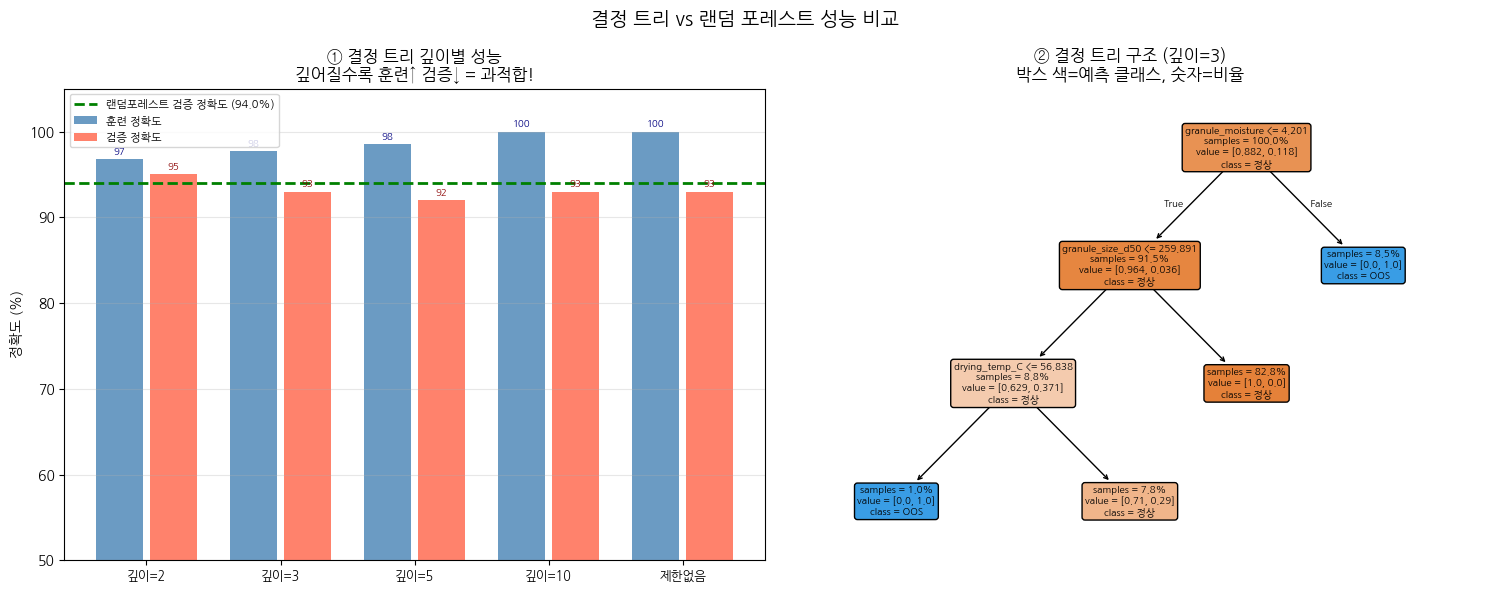

📊 결정 트리 vs 랜덤 포레스트 성능 비교
  결정 트리(깊이=2  )  훈련:96.8%  검증:95.0%  
  결정 트리(깊이=3  )  훈련:97.8%  검증:93.0%  
  결정 트리(깊이=5  )  훈련:98.5%  검증:92.0%  
  결정 트리(깊이=10 )  훈련:100.0%  검증:93.0%  
  결정 트리(제한없음  )  훈련:100.0%  검증:93.0%  
  랜덤 포레스트       훈련:99.8%  검증:94.0%  ✅ 안정적!

💡 랜덤 포레스트는 트리 100개의 집단지성으로 과적합을 방지합니다!


In [3]:
# ─────────────────────────────────────────────────────
# 3-A. 결정 트리 vs 랜덤 포레스트 비교 실험
# ─────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

feature_cols_dt = [c for c in df_tablet.columns if c != 'OOS']
X_dt = df_tablet[feature_cols_dt]
y_dt = df_tablet['OOS']
X_tr, X_te, y_tr, y_te = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

# ── 결정 트리: 깊이별로 학습해서 과적합 관찰 ──
depth_list    = [2, 3, 5, 10, None]
depth_labels  = ['깊이=2', '깊이=3', '깊이=5', '깊이=10', '제한없음']
train_accs, test_accs = [], []
for depth in depth_list:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_tr, y_tr)
    train_accs.append(accuracy_score(y_tr, dt.predict(X_tr)))
    test_accs.append( accuracy_score(y_te, dt.predict(X_te)))

# ── 랜덤 포레스트 학습 ──
rf_cmp = RandomForestClassifier(n_estimators=100, max_depth=5,
                                random_state=42, class_weight='balanced')
rf_cmp.fit(X_tr, y_tr)
rf_tr_acc = accuracy_score(y_tr, rf_cmp.predict(X_tr))
rf_te_acc = accuracy_score(y_te, rf_cmp.predict(X_te))

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('결정 트리 vs 랜덤 포레스트 성능 비교', fontsize=14, fontweight='bold')

# 그래프 ①: 깊이별 정확도 — 과적합 확인
ax = axes[0]
x = np.arange(len(depth_labels))
ax.bar(x - 0.2, [a*100 for a in train_accs], 0.35,
       label='훈련 정확도', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, [a*100 for a in test_accs],  0.35,
       label='검증 정확도', color='tomato',    alpha=0.8)
ax.axhline(rf_te_acc*100, color='green', ls='--', lw=2,
           label=f'랜덤포레스트 검증 정확도 ({rf_te_acc*100:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(depth_labels, fontsize=9)
ax.set_ylabel('정확도 (%)'); ax.set_ylim(50, 105)
ax.set_title('① 결정 트리 깊이별 성능\n깊어질수록 훈련↑ 검증↓ = 과적합!')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    ax.text(i-0.2, tr*100+0.5, f'{tr*100:.0f}', ha='center', fontsize=7, color='navy')
    ax.text(i+0.2, te*100+0.5, f'{te*100:.0f}', ha='center', fontsize=7, color='darkred')

# 그래프 ②: 결정 트리 구조 시각화 (깊이=3)
ax = axes[1]
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_tr, y_tr)
plot_tree(dt_viz, feature_names=feature_cols_dt,
          class_names=['정상','OOS'], filled=True, fontsize=7,
          ax=ax, rounded=True, impurity=False, proportion=True)
ax.set_title('② 결정 트리 구조 (깊이=3)\n박스 색=예측 클래스, 숫자=비율')

plt.tight_layout()
plt.show()

print(f"{'='*55}")
print(f"📊 결정 트리 vs 랜덤 포레스트 성능 비교")
print(f"{'='*55}")
for lbl, tr, te in zip(depth_labels, train_accs, test_accs):
    over = '← 과적합!' if tr - te > 0.15 else ''
    print(f"  결정 트리({lbl:6s})  훈련:{tr*100:.1f}%  검증:{te*100:.1f}%  {over}")
print(f"  랜덤 포레스트       훈련:{rf_tr_acc*100:.1f}%  검증:{rf_te_acc*100:.1f}%  ✅ 안정적!")
print(f"\n💡 랜덤 포레스트는 트리 100개의 앙상블로 과적합을 방지합니다!")

In [6]:
# ─────────────────────────────────────────────────────
# 3-2. 훈련/검증 데이터 분리 및 모델 학습
# ─────────────────────────────────────────────────────

# 입력 변수(X)와 목표 변수(y) 분리
feature_cols = [c for c in df_tablet.columns if c != 'OOS']
X = df_tablet[feature_cols]    # 8개 공정 파라미터
y = df_tablet['OOS']           # OOS 여부 (0 또는 1)

# 훈련(80%)과 검증(20%)으로 분리
# stratify=y: OOS/정상 비율을 훈련/검증 세트에서 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ 데이터 분리 완료:")
print(f"   훈련 데이터: {len(X_train)}배치 (OOS {y_train.sum()}개)")
print(f"   검증 데이터: {len(X_test)}배치 (OOS {y_test.sum()}개)")

# ── Random Forest 모델 학습 ──
rf_model = RandomForestClassifier(
    n_estimators=100,    # 결정 트리 100개
    max_depth=5,         # 트리 최대 깊이 (과적합 방지)
    random_state=42,     # 재현성 보장
    class_weight='balanced'  # OOS가 적을 때 균형 보정
)

rf_model.fit(X_train, y_train)   # 훈련 데이터로 학습
print("\n✅ Random Forest 모델 학습 완료!")

# 예측 수행
y_pred      = rf_model.predict(X_test)            # 클래스 예측 (0 또는 1)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]  # OOS 확률 예측 (0~1)

# 성능 평가
auc = roc_auc_score(y_test, y_pred_prob)
print(f"\n📈 모델 성능:")
print(f"   AUC-ROC: {auc:.3f}  (1.0에 가까울수록 우수)")
print()
print(classification_report(y_test, y_pred, target_names=['정상(Pass)', 'OOS(Fail)']))


✅ 데이터 분리 완료:
   훈련 데이터: 400배치 (OOS 47개)
   검증 데이터: 100배치 (OOS 12개)

✅ Random Forest 모델 학습 완료!

📈 모델 성능:
   AUC-ROC: 0.978  (1.0에 가까울수록 우수)

              precision    recall  f1-score   support

    정상(Pass)       0.95      0.99      0.97        88
   OOS(Fail)       0.88      0.58      0.70        12

    accuracy                           0.94       100
   macro avg       0.91      0.79      0.83       100
weighted avg       0.94      0.94      0.93       100



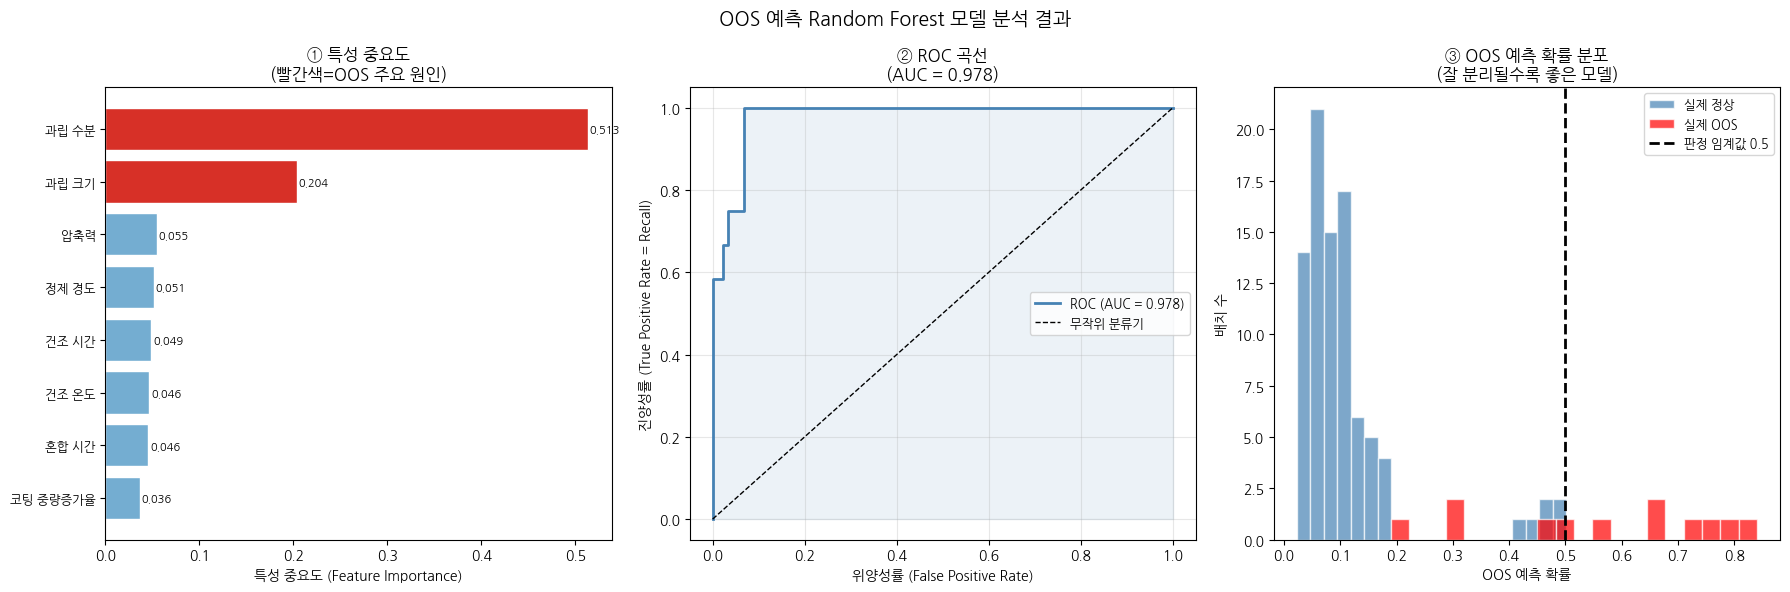


🔮 신규 배치 실시간 OOS 예측 시뮬레이션
  배치 1: OOS 확률 12.3%  →  ✅ 정상 예측
  배치 2: OOS 확률 70.4%  →  🚨 OOS 위험! 사전 조치 필요
  배치 3: OOS 확률 7.8%  →  ✅ 정상 예측

✅ 예제 3 완료!
📌 핵심 인사이트: 최종 검사 전에 공정 데이터만으로 OOS를 예측하여
   사후 폐기 → 사전 예방으로 전환, CAPA 비용과 납기 지연을 줄입니다.


In [7]:
# ─────────────────────────────────────────────────────
# 3-3. 특성 중요도 분석 및 시각화
# ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('OOS 예측 Random Forest 모델 분석 결과', fontsize=14, fontweight='bold')

# ── 그래프 ①: 특성 중요도 (어떤 공정 변수가 OOS에 가장 영향?) ──
ax = axes[0]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances_sorted = importances.sort_values(ascending=True)   # 오름차순 정렬

colors = ['#d73027' if v > 0.15 else '#74add1' for v in importances_sorted]
bars = ax.barh(range(len(importances_sorted)), importances_sorted.values,
               color=colors, edgecolor='white')
ax.set_yticks(range(len(importances_sorted)))
ax.set_yticklabels([
    '코팅 중량증가율', '혼합 시간', '건조 온도', '건조 시간',
    '정제 경도', '압축력', '과립 크기', '과립 수분'
], fontsize=9)
ax.set_xlabel('특성 중요도 (Feature Importance)')
ax.set_title('① 특성 중요도\n(빨간색=OOS 주요 원인)')
for i, v in enumerate(importances_sorted.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# ── 그래프 ②: ROC 곡선 ──
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='무작위 분류기')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('위양성률 (False Positive Rate)')
ax.set_ylabel('진양성률 (True Positive Rate = Recall)')
ax.set_title(f'② ROC 곡선\n(AUC = {auc:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 그래프 ③: OOS 예측 확률 분포 (정상 vs OOS 배치) ──
ax = axes[2]
ax.hist(y_pred_prob[y_test == 0], bins=20, alpha=0.7, color='steelblue',
        label='실제 정상', edgecolor='white')
ax.hist(y_pred_prob[y_test == 1], bins=20, alpha=0.7, color='red',
        label='실제 OOS', edgecolor='white')
ax.axvline(0.5, color='black', ls='--', lw=2, label='판정 임계값 0.5')
ax.set_xlabel('OOS 예측 확률')
ax.set_ylabel('배치 수')
ax.set_title('③ OOS 예측 확률 분포\n(잘 분리될수록 좋은 모델)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('예제3_OOS예측모델.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────
# 3-4. 새로운 배치에 대한 실시간 OOS 예측 시뮬레이션
# ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("🔮 신규 배치 실시간 OOS 예측 시뮬레이션")
print("=" * 55)

# 새로 들어온 배치 3개의 공정 데이터
new_batches = pd.DataFrame({
    'granule_moisture'   : [3.2, 4.8, 3.0],   # 배치별 과립 수분
    'granule_size_d50'   : [305, 250, 310],
    'drying_temp_C'      : [60,  55,  62],
    'drying_time_min'    : [45,  35,  48],
    'blend_time_min'     : [15,  12,  16],
    'compaction_force_kN': [12,  16,  11],
    'tablet_hardness_N'  : [80,  70,  85],
    'coat_weight_gain'   : [3.0, 3.5, 2.9],
})

# OOS 확률 예측
oos_probs = rf_model.predict_proba(new_batches)[:, 1]
decisions = ['🚨 OOS 위험! 사전 조치 필요' if p > 0.5 else '✅ 정상 예측' for p in oos_probs]

for i, (prob, decision) in enumerate(zip(oos_probs, decisions)):
    print(f"  배치 {i+1}: OOS 확률 {prob*100:.1f}%  →  {decision}")

print("\n✅ 예제 3 완료!")
print("📌 핵심 인사이트: 최종 검사 전에 공정 데이터만으로 OOS를 예측하여")
print("   사후 폐기 → 사전 예방으로 전환, CAPA 비용과 납기 지연을 줄입니다.")


---
## ✅ 예제 3 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | 21 CFR 211.192 OOS 조사 → AI로 사전 예방 |
| **AI 기법** | Random Forest 분류 · Feature Importance · DT vs RF 비교 |
| **핵심 성과** | OOS 예측 정확도 · CPP 중요도 순위 · 과적합 방지 시각화 |
| **다음 단계** | OOS 분류(지도학습) → 예제 4(이상탐지, 비지도학습)로 확장 |

> 💡 **기억할 한 줄**: "단일 결정 트리는 훈련 데이터를 암기하고, 랜덤 포레스트는 패턴을 학습한다 — 앙상블의 힘."